### Module 2.
Module 2 is all about algorithms, mathematical models and numeric analisis used in Data Science. 

#### Least Squares algorithms:
To understand this type of algorithm, we can run back to the simplest, yet insightful model **Linear Regression**.

Linear Regression can be expressed with Matrices and vectors, where:
$$
\text{we have an input: } X_{[n*2]} = ((1, ptot_1),..., (1, ptot_n))
$$
$$
\text{
an output:  } Y_{[n*1]} = (y_0, y_1, ..., y_n)
$$
$$
\text{ 
with coeficients like:  } \beta_{[2*1]} = (\beta_0, \beta_1)
$$
$$
\text{ 
and an error component such as: }
\epsilon_{[n*1]} = (\epsilon_1, ..., \epsilon_n)
$$ 

When we speak about ordinary least squares (OLS), we know we have a set of observations:
$$
\set{(y_i, z^T_i)}^n_{i=1}
$$

With a set of base functions:
$$
Z^T_i = (z_{i0}, z_{i1}, ..., z_{ip})^T
$$
And a coeficient vector such as:
$$
\beta = (\beta_0, ..., \beta_p)^p
$$

The whole idea of training a Linear Regression model is to minimize the following function:
$$
\min_{\beta \in \R^{p+1}} L(\beta; y, z)
= ||y - Z\beta||²_2
= (y - Z\beta)^T (y-Z\beta)
$$

Note that, solving for the normal equations, we can estimate the values of the $\beta$ components. 
The estimators are defined like this:
$$
\hat{\beta} = (Z^T Z) ^{-1} Z^T y
$$

Thus, when we speak about linearity, a regression model can be expressed using the following base functions:
$$
z_0 = \set{1, z_1 = x_1, ..., z_p = x_p}
$$
Meaning that for the $i^{th}$ row of $Z\beta$ we get:
$$
z^T_i \beta = \beta_0 + \beta_1 x_{i1} + ... + \beta_p x_{ip}
$$

We can note we do not care about the predictors ($x$) to determine if a model is linear or not, rather on the coeficients. We can care as little on the functions the predictors have. 

For instance, as the coeficients in this model are linear, we call this a linear model.
$$
y = \beta_0 + \beta_1 x + \beta_2 x³ + \beta_3 x^{log(x)}
$$

In contrast. this model would not be:
$$
y = \beta_0 + e^{-\beta_1 x_1} 
$$

Before getting into the code example, we must note that the *Ordinary Least Squares* algorithm only works efficiently if the following criteria are met:
- Linearity between the output and a functional form of the predictors. 
- Zero average for all error components. 
- Constant variance in error components. 
- No autocorrelation between error components. 
- Independency of predictors. 

#### Code Example

In [43]:
# We'll compute an example bellow:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
data = pd.read_csv("data/water_quality.csv", encoding="latin1")
data.head()

,ESTACION,fecha,CLOROF_A,OD_mg/L_FON,P_TOT,TEMP_AGUA_FON
0,"LAGO DE CHAPALA, ESTACION LACUSTRE 01",01/09/2022,NaN,7.57,NaN,26.0
1,"LAGO DE CHAPALA, ESTACION LACUSTRE 01",12/12/2012,NaN,7.93,0.4647,NaN
2,"LAGO DE CHAPALA, ESTACION LACUSTRE 01",26/04/2013,125.8848,NaN,0.5795,22.1
3,"LAGO DE CHAPALA, ESTACION LACUSTRE 01",21/09/2013,13.9390,NaN,0.5106,22.8
4,"LAGO DE CHAPALA, ESTACION LACUSTRE 01",26/02/2014,11.2100,6.71,0.5890,21.3


In [45]:
data.rename(columns = {"ESTACION": "site",
                       "fecha": "date",
                       "CLOROF_A": "clorof_a",
                       "OD_mg/L_FON": "od_fon",
                       "P_TOT": "p_tot",
                       "TEMP_AGUA_FON": "temp_fon"}, inplace = True)

data["date"] = pd.to_datetime(data["date"], format= "%d/%m/%Y")
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 461 entries, 0 to 460
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   site      461 non-null    str           
 1   date      461 non-null    datetime64[us]
 2   clorof_a  411 non-null    float64       
 3   od_fon    253 non-null    float64       
 4   p_tot     439 non-null    float64       
 5   temp_fon  273 non-null    float64       
dtypes: datetime64[us](1), float64(4), str(1)
memory usage: 21.7 KB


In [46]:
data = data.sort_values(by = "date")
data.tail()

,site,date,clorof_a,od_fon,p_tot,temp_fon
355,"LAGO DE CHAPALA, ESTACION LACUSTRE 23",2022-09-01,NaN,6.49,NaN,23.0
124,"LAGO DE CHAPALA, ESTACION LACUSTRE 17",2022-09-01,NaN,5.62,NaN,25.0
443,"LAGO DE CHAPALA, ESTACION LACUSTRE 02",2022-09-01,NaN,6.48,NaN,25.0
408,"LAGO DE CHAPALA, ESTACION LACUSTRE 04",2022-09-01,NaN,6.40,NaN,24.0
0,"LAGO DE CHAPALA, ESTACION LACUSTRE 01",2022-09-01,NaN,7.57,NaN,26.0


In [47]:
data["days"] = (data["date"] - data["date"].min()).dt.days

In [48]:
# As the most complete site is station 11, we wil only use that:

stat11_data = data[data["site"] == "LAGO DE CHAPALA, ESTACION LACUSTRE 11"].copy()
stat11_data.head()

,site,date,clorof_a,od_fon,p_tot,temp_fon,days
302,"LAGO DE CHAPALA, ESTACION LACUSTRE 11",2012-12-04,4.3900,7.24,0.3988,NaN,13
303,"LAGO DE CHAPALA, ESTACION LACUSTRE 11",2013-04-05,6.8096,NaN,0.5409,21.3,135
304,"LAGO DE CHAPALA, ESTACION LACUSTRE 11",2013-09-20,6.4620,NaN,0.4748,23.8,303
305,"LAGO DE CHAPALA, ESTACION LACUSTRE 11",2014-02-25,16.5400,6.07,0.5740,20.5,461
306,"LAGO DE CHAPALA, ESTACION LACUSTRE 11",2014-09-04,20.9000,5.80,0.6370,23.8,652


In [49]:
# As we have two coeficients (\beta_0 & \beta_1), we need to use an X matrix to fit these coeficients. 

X = np.column_stack((np.ones(len(stat11_data)), stat11_data["p_tot"]))

In [50]:
y = stat11_data["clorof_a"].to_numpy()

In [51]:
beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

In [52]:
y_hat = X @ beta_hat
residuals = y- y_hat
sigma_hat = np.sqrt((residuals**2).sum())/ (len(X) - len(beta_hat))

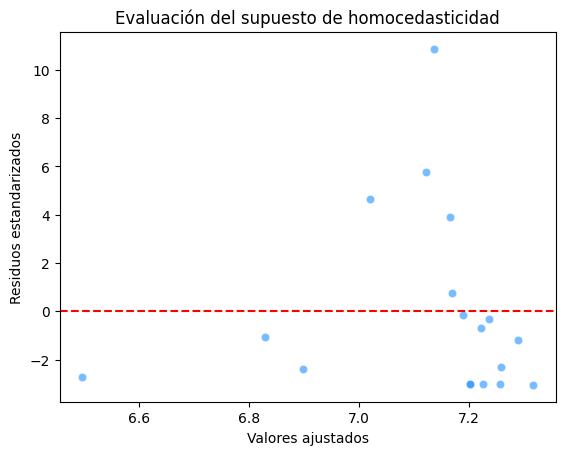

In [53]:
std_residuals = residuals/sigma_hat
sns.scatterplot(x = y_hat, y = std_residuals, color = "dodgerblue", alpha = 0.6)
plt.axhline(0, linestyle = "--", color = "red")
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos estandarizados")
plt.title("Evaluación del supuesto de homocedasticidad")
plt.show()


In [54]:
import statsmodels.stats.api as sms

test = sms.het_breuschpagan(residuals, X)

In [55]:
from statsmodels.compat import lzip

names = ["Lagrange multiplier statistic", "p-value",
         "f-value", "f p-value"]
lzip(names, test)

[('Lagrange multiplier statistic', np.float64(3.482507872876184e-05)),
 ('p-value', np.float64(0.9952914889472495)),
 ('f-value', np.float64(3.0955685427036077e-05)),
 ('f p-value', np.float64(0.995629547150007))]